# Random Forest: A Comprehensive Guide

Random Forest is an ensemble learning method that constructs multiple decision trees during training and outputs the mode of the classes (classification) or mean prediction (regression) of the individual trees.

In this notebook, we'll cover:
1. Basic concepts of Random Forest
2. Data preparation and visualization
3. Model implementation from scratch
4. Using scikit-learn for Random Forest
5. Model evaluation and interpretation

# Simple Explanation: What Does the Code Below Do?

Imagine you need to make an important decision and you ask 100 different experts for their opinions. Each expert looks at slightly different information. You then go with the majority vote. That's exactly how a Random Forest works!

- Each 'expert' is a Decision Tree trained on a random subset of the data (Bootstrap Sampling).
- Each tree also looks at a random subset of features at each split (Feature Randomness).
- The final prediction combines all tree predictions (Ensemble Voting).

Here's what the code does:
1. Loads the breast cancer dataset (binary classification).
2. Builds a Random Forest from scratch using multiple Decision Trees.
3. Uses scikit-learn's optimized Random Forest for comparison.
4. Evaluates performance and explores feature importances.

In short: Many imperfect trees together make better predictions than any single tree!

In [1]:
# Create a virtual environment and install required libraries
import os
import sys

venv_dir = 'ml_env'
if not os.path.exists(venv_dir):
    os.system(f'{sys.executable} -m venv {venv_dir}')
    print(f'Virtual environment created at {venv_dir}')
else:
    print(f'Virtual environment already exists at {venv_dir}')

pip_path = os.path.join(venv_dir, 'Scripts', 'pip')
if sys.platform == 'win32':
    pip_path += '.exe'

if os.path.exists(pip_path):
    os.system(f'"{pip_path}" install numpy pandas matplotlib seaborn scikit-learn')
    print('Required libraries installed in the virtual environment.')
else:
    print('Could not find pip in the virtual environment. Please check your Python installation.')

Virtual environment already exists at ml_env
Required libraries installed in the virtual environment.


# 1. Required Libraries

Let's start by importing the necessary libraries:
- NumPy: For numerical computations
- Pandas: For data manipulation
- Matplotlib: For basic plotting
- Seaborn: For statistical visualizations
- Scikit-learn: For machine learning tools

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Set the style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# 2. Generating Sample Data

We'll use the Breast Cancer Wisconsin dataset - a binary classification problem:
- Malignant (cancerous) = 0
- Benign (non-cancerous) = 1

The dataset has 30 features computed from cell nucleus images.

Dataset shape: (569, 30)
Classes: ['malignant' 'benign']
Class distribution: [212 357]


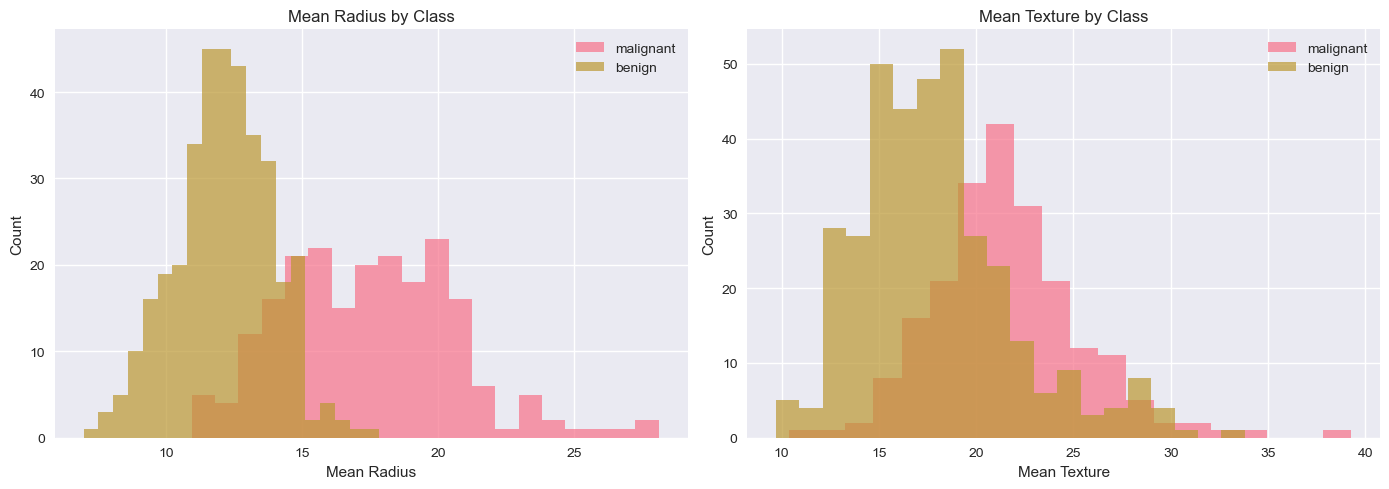

In [3]:
# Load dataset
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target
feature_names = cancer.feature_names
class_names = cancer.target_names

print('Dataset shape:', X.shape)
print('Classes:', class_names)
print('Class distribution:', np.bincount(y))

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Visualize top features
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature distributions for two key features
for i, cls in enumerate(class_names):
    subset = df[df['target'] == i]
    axes[0].hist(subset['mean radius'], alpha=0.7, label=cls, bins=20)
axes[0].set_xlabel('Mean Radius')
axes[0].set_ylabel('Count')
axes[0].set_title('Mean Radius by Class')
axes[0].legend()

for i, cls in enumerate(class_names):
    subset = df[df['target'] == i]
    axes[1].hist(subset['mean texture'], alpha=0.7, label=cls, bins=20)
axes[1].set_xlabel('Mean Texture')
axes[1].set_ylabel('Count')
axes[1].set_title('Mean Texture by Class')
axes[1].legend()

plt.tight_layout()
plt.show()

# 3. Implementing Random Forest from Scratch

Key concepts:
1. **Bootstrap Sampling**: Each tree is trained on a random sample (with replacement) of the training data.
2. **Feature Randomness**: At each split, only a random subset of features is considered.
3. **Ensemble Voting**: Final prediction is the majority vote across all trees.

This combination reduces variance and helps avoid overfitting!

In [4]:
class RandomForestScratch:
    def __init__(self, n_trees=10, max_depth=5, max_features='sqrt', random_state=42):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.max_features = max_features
        self.random_state = random_state
        self.trees = []

    def _bootstrap_sample(self, X, y, rng):
        """Create a bootstrap sample of the data."""
        n_samples = X.shape[0]
        indices = rng.choice(n_samples, size=n_samples, replace=True)
        return X[indices], y[indices]

    def fit(self, X, y):
        rng = np.random.RandomState(self.random_state)
        self.trees = []

        if self.max_features == 'sqrt':
            n_features = int(np.sqrt(X.shape[1]))
        else:
            n_features = X.shape[1]

        for i in range(self.n_trees):
            # Bootstrap sample
            X_sample, y_sample = self._bootstrap_sample(X, y, rng)

            # Random feature selection per tree
            feature_indices = rng.choice(X.shape[1], size=n_features, replace=False)

            # Train a decision tree on the sample and selected features
            tree = DecisionTreeClassifier(max_depth=self.max_depth, 
                                          max_features=n_features,
                                          random_state=rng.randint(0, 10000))
            tree.fit(X_sample[:, feature_indices], y_sample)
            self.trees.append((tree, feature_indices))

    def predict(self, X):
        # Collect predictions from each tree
        tree_preds = [tree.predict(X[:, features]) for tree, features in self.trees]
        # Majority vote
        tree_preds = np.array(tree_preds)  # shape: (n_trees, n_samples)
        # Take mode for each sample
        from scipy import stats
        result = stats.mode(tree_preds, axis=0)
        return result.mode.flatten()

# Train scratch RF
rf_scratch = RandomForestScratch(n_trees=50, max_depth=5, random_state=42)
rf_scratch.fit(X_train, y_train)
y_pred_scratch = rf_scratch.predict(X_test)
print(f'Random Forest (Scratch) Accuracy: {accuracy_score(y_test, y_pred_scratch):.4f}')

Random Forest (Scratch) Accuracy: 0.9737


# 4. Using Scikit-learn's Random Forest

Now let's use scikit-learn's highly optimized implementation which is what you should use in practice.

In [5]:
# Train scikit-learn Random Forest
rf_sklearn = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_sklearn.fit(X_train, y_train)
y_pred = rf_sklearn.predict(X_test)

print(f'Random Forest (Sklearn) Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'\nClassification Report:\n{classification_report(y_test, y_pred, target_names=class_names)}')

Random Forest (Sklearn) Accuracy: 0.9649

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.93      0.95        43
      benign       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



# 5. Model Evaluation

Let's evaluate the model performance and explore what features the Random Forest finds most important.

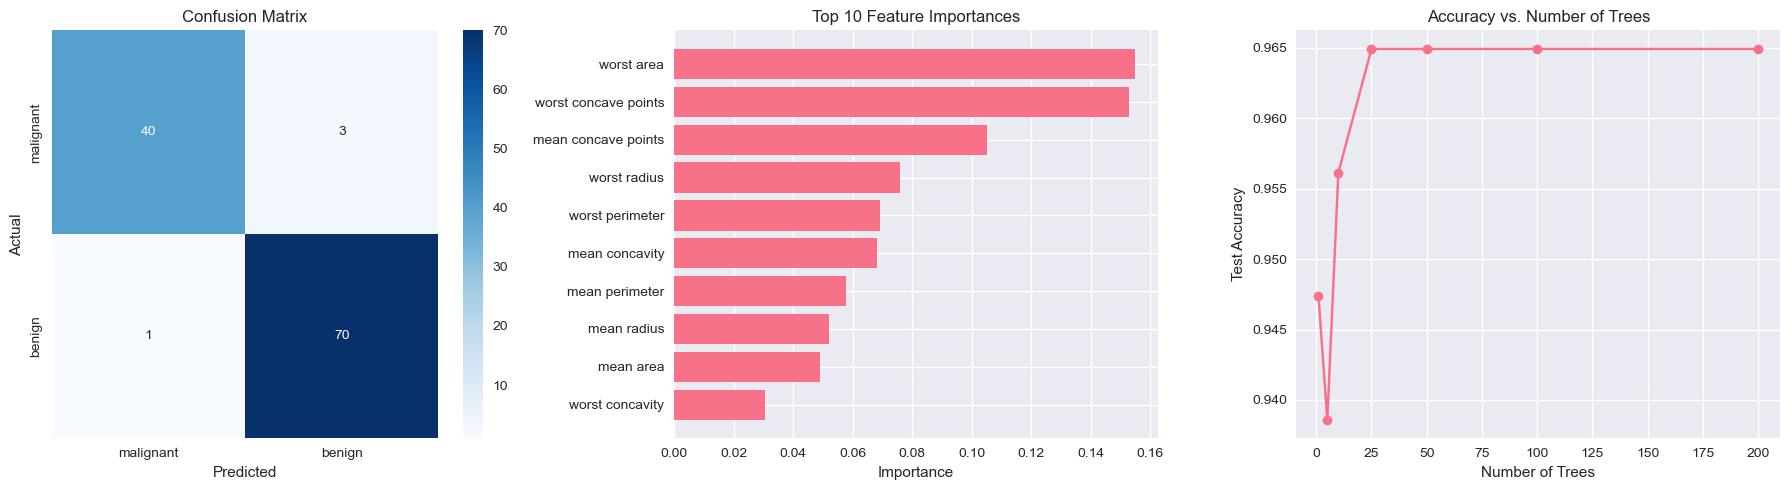


Key Insight: Adding more trees improves accuracy up to a point, after which gains diminish.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, 
            yticklabels=class_names, ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')

# 2. Top 10 Feature Importances
importances = rf_sklearn.feature_importances_
indices = np.argsort(importances)[-10:]  # top 10
axes[1].barh(range(10), importances[indices])
axes[1].set_yticks(range(10))
axes[1].set_yticklabels([feature_names[i] for i in indices])
axes[1].set_xlabel('Importance')
axes[1].set_title('Top 10 Feature Importances')

# 3. Accuracy vs Number of Trees
n_estimators_range = [1, 5, 10, 25, 50, 100, 200]
test_accs = []
for n in n_estimators_range:
    rf = RandomForestClassifier(n_estimators=n, max_depth=5, random_state=42)
    rf.fit(X_train, y_train)
    test_accs.append(accuracy_score(y_test, rf.predict(X_test)))

axes[2].plot(n_estimators_range, test_accs, marker='o')
axes[2].set_xlabel('Number of Trees')
axes[2].set_ylabel('Test Accuracy')
axes[2].set_title('Accuracy vs. Number of Trees')
axes[2].grid(True)

plt.tight_layout()
plt.show()

print('\nKey Insight: Adding more trees improves accuracy up to a point, after which gains diminish.')

# Conclusions and Key Takeaways
Random Forest is a highly robust, versatile ensemble learning method that operates by constructing a multitude of decision trees at training time.
- **Bagging**: It trains many independent trees on random subsets of the data (bootstrapping) and averages their predictions (aggregation) to reduce variance.
- **Feature Randomness**: It adds an extra layer of randomness by selecting a random subset of features at each split, preventing a few strong features from dominating all the trees.
- Excellent "out-of-the-box" performance requiring minimal hyperparameter tuning.

# Pros and Cons
**Pros:**
- Incredibly resistant to overfitting compared to an individual decision tree.
- Handles missing values, outliers, and non-linear data exceptionally well without requiring scaling.
- Provides a reliable estimate of Feature Importance natively.

**Cons:**
- Models can become very large and consume massive amounts of memory with thousands of trees.
- Prediction time is slower than a single tree, making it challenging for real-time applications with strict latency requirements.
- It is a "black box" model, losing the beautiful interpretability of a single decision tree.

# 15 Interview Questions and Answers

1. **How does a Random Forest work?**
   *Answer*: It builds an ensemble of decision trees. Each tree is trained on a bootstrapped sample of the data. During tree building, each node split is determined by searching over a random subset of features rather than all features. The final prediction averages the output of all trees (regression) or takes a majority vote (classification).

2. **What is Bootstrapping?**
   *Answer*: Randomly sampling the training dataset with replacement. That means some data points will be picked multiple times for a single tree, and some won't be picked at all.

3. **What is OOB (Out-Of-Bag) Error?**
   *Answer*: Because of bootstrapping, roughly 36% of the data is left out of the training set for any specific tree. This "out-of-bag" data can be passed through that tree to calculate an unbiased validation error, often eliminating the need for a separate validation set.

4. **Why do we pick a random subset of features for each split?**
   *Answer*: To force the trees to be diverse entirely uncorrelated. If we didn't do this, a single dominant feature would be chosen as the first split in almost every tree, making the trees highly correlated and defeating the purpose of averaging to reduce variance.

5. **Can a Random Forest overfit?**
   *Answer*: While vastly less prone to overfitting than a single tree, it can technically overfit if the trees are allowed to grow to infinite depth on very noisy data. However, adding *more trees* to the forest does not cause overfitting; it just plateaus in performance.

6. **How do you tune the hyperparameters of a Random Forest?**
   *Answer*: Key parameters are `n_estimators` (number of trees, higher is usually better but slower), `max_depth` (controls overfit of individual trees), and `max_features` (size of the random subsets of features considered at each split, usually sqrt(N) for classification or N/3 for regression).

7. **How does Random Forest calculate Feature Importance?**
   *Answer*: It typically uses Gini Importance (Mean Decrease Impurity). It calculates how much a specific feature decreases the Gini impurity across all the trees where it was used for a split, averaging that reduction over the whole forest.

8. **Is feature scaling required for Random Forest?**
   *Answer*: No. Because the underlying base estimators are decision trees, which make splits based purely on the rank/ordering of values, standardizing or normalizing the data has absolutely zero effect on the model.

9. **What is the difference between AdaBoost and Random Forest?**
   *Answer*: Random Forest builds independent deep trees in parallel (bagging) aiming to reduce variance. AdaBoost builds shallow stumps sequentially (boosting) aiming to reduce bias by focusing on previously misclassified samples.

10. **Why would a Random Forest fail to extrapolate outside the training data range?**
    *Answer*: Because it is bound by the specific terminal leaf values of its trees. If a regression tree is trained on target values between 10 and 50, it is mathematically impossible for the Random Forest to ever predict a value of 55, no matter what the input is.

11. **Are Random Forests parametric or non-parametric?**
    *Answer*: Non-parametric. They make no assumptions about the underlying distribution of the data or the functional form of the relationship.

12. **What is the impact of the `n_estimators` argument?**
    *Answer*: Increasing it increases the number of trees. This generally improves generalization by smoothing the average vote, but it scales the training time and memory requirements linearly. It yields diminishing returns past a certain point.

13. **Why is Random Forest often a preferred first baseline model over Neural Networks?**
    *Answer*: Random forests require massively less data to perform well, practically no data preprocessing (scaling, encoding), extremely little hyperparameter tuning, and train incredibly quickly, making them a vastly superior rapid baseline.

14. **How does Random Forest handle imbalanced data?**
    *Answer*: Natively, it can struggle. But techniques like Random Forest with class weighting (assigning higher penalty to minority class misclassifications) or Balanced Random Forest (undersampling the majority class in the bootstrap sample) manage it effectively.

15. **How does the time complexity scale compared to a single Decision Tree?**
    *Answer*: If a single tree takes O(M * N log N), a random forest of T trees takes O(T * M * N log N) for training. However, because the trees are completely independent, this can be trivially parallelized across all CPU cores, drastically reducing real-world wall-clock time.
